Sample experiment to run different simulations for a data center, assuming different geographical locations, by providing different carbon trace files in order to map electricity usage to the respective areas carbon trace

In [1]:
import os
import subprocess
import platform

# Detect OS and set JAVA_HOME accordingly
os_type = platform.system()

if os_type == "Darwin":  # macOS
    os.environ["JAVA_HOME"] = "/opt/homebrew/opt/openjdk@21"
    os.environ["PATH"] = f"{os.environ['JAVA_HOME']}/bin:" + os.environ["PATH"]
elif os_type == "Linux":  # Ubuntu/Linux
    java_home = os.environ.get("JAVA_HOME", "/usr/lib/jvm/java-21-openjdk-amd64")
    os.environ["JAVA_HOME"] = java_home
    os.environ["PATH"] = f"{os.environ['JAVA_HOME']}/bin:" + os.environ["PATH"]
else:
    print(
        f"Warning: Unsupported OS ({os_type}). JAVA_HOME may need to be set manually."
    )

# change experiment name based on json filename and name field inside json
experimentName = "custom_scheduler_experiment"  # timeshift_experiment , custom_scheduler_experiment , sample_experiment
pathToScenario = f"input/experiments/{experimentName}.json"

subprocess.run(
    [
        "OpenDCExperimentRunner/bin/OpenDCExperimentRunner",
        "--experiment-path",
        pathToScenario,
    ]
)

Exception in thread "main" kotlinx.serialization.SerializationException: org.opendc.compute.simulator.scheduler.ComputeSchedulerEnum does not contain element with name 'CarbonAwareWorkflow'
	at kotlinx.serialization.json.internal.JsonNamesMapKt.getJsonNameIndexOrThrow(JsonNamesMap.kt:107)
	at kotlinx.serialization.json.internal.JsonNamesMapKt.getJsonNameIndexOrThrow$default(JsonNamesMap.kt:104)
	at kotlinx.serialization.json.internal.AbstractJsonTreeDecoder.decodeTaggedEnum(TreeJsonDecoder.kt:87)
	at kotlinx.serialization.json.internal.AbstractJsonTreeDecoder.decodeTaggedEnum(TreeJsonDecoder.kt:36)
	at kotlinx.serialization.internal.TaggedDecoder.decodeEnum(Tagged.kt:234)
	at kotlinx.serialization.internal.EnumSerializer.deserialize(Enums.kt:139)
	at kotlinx.serialization.internal.EnumSerializer.deserialize(Enums.kt:105)
	at kotlinx.serialization.json.internal.PolymorphicKt.decodeSerializableValuePolymorphic(Polymorphic.kt:61)
	at kotlinx.serialization.json.internal.AbstractJsonTreeDec

CompletedProcess(args=['OpenDCExperimentRunner/bin/OpenDCExperimentRunner', '--experiment-path', 'input/experiments/custom_scheduler_experiment.json'], returncode=1)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_host_BE = pd.read_parquet(
    f"output/{experimentName}/raw-output/0/seed=0/host.parquet"
)
df_powerSource_BE = pd.read_parquet(
    f"output/{experimentName}/raw-output/0/seed=0/powerSource.parquet"
)
df_task_BE = pd.read_parquet(
    f"output/{experimentName}/raw-output/0/seed=0/task.parquet"
)
df_service_BE = pd.read_parquet(
    f"output/{experimentName}/raw-output/0/seed=0/service.parquet"
)

df_host_NL = pd.read_parquet(
    f"output/{experimentName}/raw-output/1/seed=0/host.parquet"
)
df_powerSource_NL = pd.read_parquet(
    f"output/{experimentName}/raw-output/1/seed=0/powerSource.parquet"
)
df_task_NL = pd.read_parquet(
    f"output/{experimentName}/raw-output/1/seed=0/task.parquet"
)
df_service_NL = pd.read_parquet(
    f"output/{experimentName}/raw-output/1/seed=0/service.parquet"
)

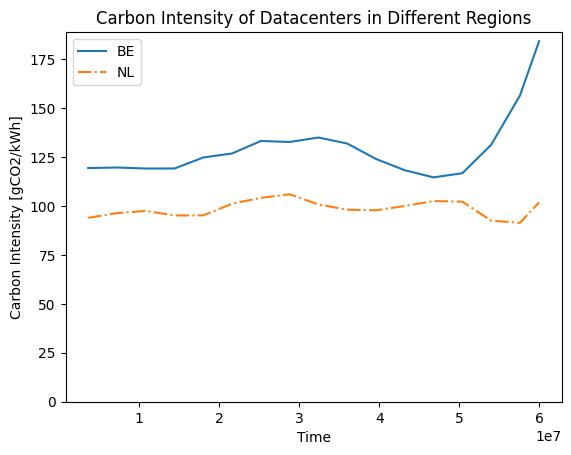

In [ ]:
plt.plot(
    df_powerSource_BE["timestamp"], df_powerSource_BE["carbon_intensity"], label="BE"
)
plt.plot(
    df_powerSource_NL["timestamp"],
    df_powerSource_NL["carbon_intensity"],
    label="NL",
    linestyle="-.",
)

plt.legend()
plt.xlabel("Time")
plt.ylim([0, None])
plt.ylabel("Carbon Intensity [gCO2/kWh]")
plt.title("Carbon Intensity of Datacenters in Different Regions")

plt.show()

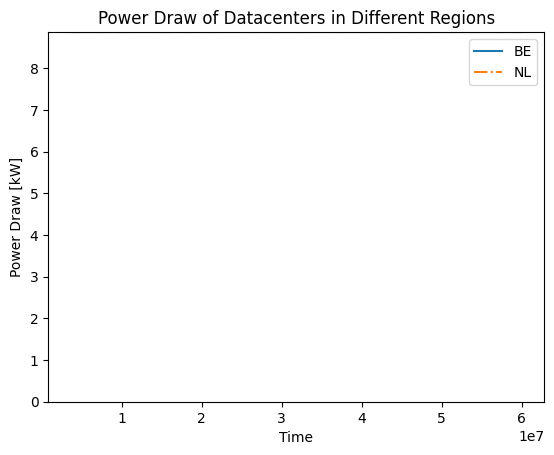

In [ ]:
plt.plot(
    df_powerSource_BE["timestamp"], df_powerSource_BE["power_draw"] / 1000, label="BE"
)
plt.plot(
    df_powerSource_NL["timestamp"],
    df_powerSource_NL["power_draw"] / 1000,
    label="NL",
    linestyle="-.",
)

plt.legend()
plt.xlabel("Time")
plt.ylim([0, None])
plt.ylabel("Power Draw [kW]")
plt.title("Power Draw of Datacenters in Different Regions")

plt.show()

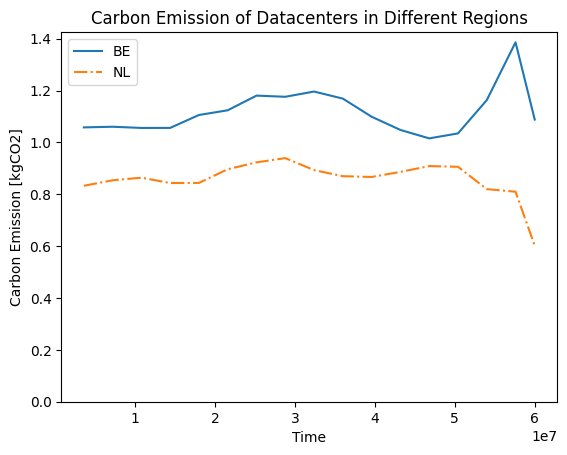

In [ ]:
plt.plot(
    df_powerSource_BE["timestamp"],
    df_powerSource_BE["carbon_emission"] / 1000,
    label="BE",
)
plt.plot(
    df_powerSource_NL["timestamp"],
    df_powerSource_NL["carbon_emission"] / 1000,
    label="NL",
    linestyle="-.",
)

plt.legend()
plt.xlabel("Time")
plt.ylim([0, None])
plt.ylabel("Carbon Emission [kgCO2]")
plt.title("Carbon Emission of Datacenters in Different Regions")

plt.show()

In [ ]:
carbon_BE = df_powerSource_BE["carbon_emission"].sum() / 1000
carbon_NL = df_powerSource_NL["carbon_emission"].sum() / 1000

print(f"Total Carbon Emission Belgium:     {carbon_BE:.2f} kgCO2")
print(f"Total Carbon Emission Netherlands: {carbon_NL:.2f} kgCO2\n")


Total Carbon Emission Belgium:     19.02 kgCO2
Total Carbon Emission Netherlands: 14.56 kgCO2

